In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score)
import shap

c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Load Data

df = pd.read_csv("WV_DCC.csv", skiprows=[1], low_memory=False)
df = df.drop(columns=['Unnamed: 0'])

# Confirming shape and class balance
print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df['Y'].mean():.4f}") 
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset shape: (30000, 31)
Default rate: 0.2212
Missing values: 0


In [ ]:
# Feature Setup

# Compute utilization ratios for all 6 months --utilization_t = BILL_AMT_t / LIMIT_BAL (X1)
# X12=BILL_AMT1, X13=BILL_AMT2, ..., X17=BILL_AMT6

bill_cols = ['X12', 'X13', 'X14', 'X15', 'X16', 'X17']
util_col_names = ['UTIL_t1', 'UTIL_t2', 'UTIL_t3', 
                  'UTIL_t4', 'UTIL_t5', 'UTIL_t6']

for i, (bill, util) in enumerate(zip(bill_cols, util_col_names)):
    df[util] = df[bill] / df['X1'].replace(0, np.nan)

df['UTIL_avg'] = df[util_col_names].mean(axis=1)

print("Utilization columns added:")
print(df[util_col_names + ['UTIL_avg']].describe().round(3))

Utilization columns added:
         UTIL_t1    UTIL_t2    UTIL_t3    UTIL_t4    UTIL_t5    UTIL_t6  \
count  30000.000  30000.000  30000.000  30000.000  30000.000  30000.000   
mean       0.424      0.411      0.392      0.360      0.333      0.319   
std        0.411      0.405      0.396      0.369      0.351      0.345   
min       -0.620     -1.396     -1.025     -1.374     -0.877     -1.510   
25%        0.022      0.018      0.016      0.014      0.011      0.008   
50%        0.314      0.296      0.273      0.242      0.212      0.185   
75%        0.830      0.806      0.755      0.668      0.602      0.582   
max        6.455      6.380     10.689      5.147      4.936      3.886   

        UTIL_avg  
count  30000.000  
mean       0.373  
std        0.352  
min       -0.233  
25%        0.030  
50%        0.285  
75%        0.688  
max        5.364  


In [ ]:
# Define Features and Target -- Include BILL_AMTs and utilization columns

drop_cols = ['Y']
X = df.drop(columns=drop_cols)
y = df['Y']

# One-hot encode repayment status, education, and marriage
# drop_first=False keeps all categories so model sees full info
categorical_cols = ['X3', 'X4', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print(f"Features used: {X.shape[1]}")
print(f"Feature names: {list(X.columns)}")

Features used: 37
Feature names: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'UTIL_t1', 'UTIL_t2', 'UTIL_t3', 'UTIL_t4', 'UTIL_t5', 'UTIL_t6', 'UTIL_avg']


In [ ]:
# Train / Validation / Test Split -- 70 / 20 / 10

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.10, 
    random_state=42, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.222,  
    random_state=42,
    stratify=y_temp
)

print(f"Train size : {X_train.shape[0]}")
print(f"Val size   : {X_val.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate : {y_test.mean():.4f}")

Train size : 21006
Val size   : 5994
Test size  : 3000
Train default rate: 0.2212
Test default rate : 0.2213


In [ ]:
# Hyperparameter Tuning with Grid Search
# 5-fold cross validation

from sklearn.metrics import make_scorer, f1_score


f1_scorer = make_scorer(f1_score)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'],  # feature selection
    'class_weight': ['balanced', {0: 1, 1: 3}]  # custom weight
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='f1',       
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Best CV F1: 0.5391


In [8]:
# Train Final Model with Best Parameters

rf_model = grid_search.best_estimator_

# Evaluate on validation set first
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

print("=== Validation Set Performance ===")
print(f"Accuracy : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall   : {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_val, y_val_prob):.4f}")

=== Validation Set Performance ===
Accuracy : 0.7886
Precision: 0.5204
Recall   : 0.5671
F1 Score : 0.5428
ROC AUC  : 0.7805


In [9]:
# Final Evaluation on Test Set

y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Test Set Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_test_prob):.4f}")

# Compare to LR baseline for reference
print("\n=== LR Baseline Results ===")
print("Accuracy : 0.8082")
print("Precision: 0.6913")
print("Recall   : 0.2396")
print("F1 Score : 0.3559")
print("ROC AUC  : 0.7095")

=== Random Forest Test Set Results ===
Accuracy : 0.7947
Precision: 0.5345
Recall   : 0.5602
F1 Score : 0.5471
ROC AUC  : 0.7841

=== LR Baseline Results ===
Accuracy : 0.8082
Precision: 0.6913
Recall   : 0.2396
F1 Score : 0.3559
ROC AUC  : 0.7095


Best threshold: 0.5235
F1 at best threshold: 0.5469


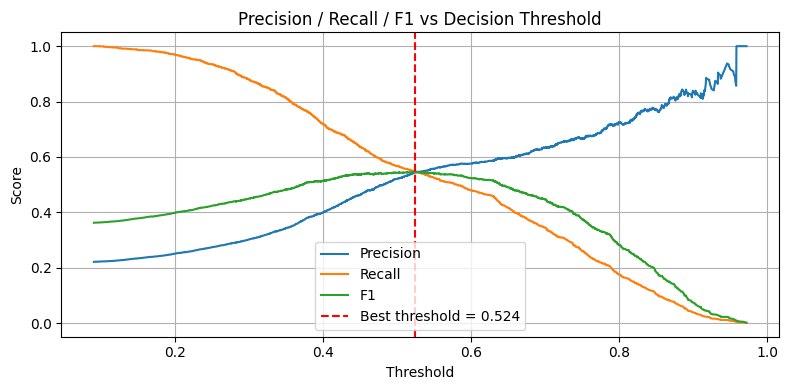


=== RF Test Set Results (Tuned Threshold) ===
Threshold  : 0.5235
Accuracy   : 0.8023
Precision  : 0.5550
Recall     : 0.5392
F1 Score   : 0.5470
ROC AUC    : 0.7841

=== RF Test Set Results (Default 0.5 Threshold) ===
Accuracy   : 0.7860
Precision  : 0.5147
Recall     : 0.5798
F1 Score   : 0.5453
ROC AUC    : 0.7785


In [ ]:
# Threshold Tuning - Find the threshold that maximizes F1 on the validation set

from sklearn.metrics import precision_recall_curve

y_val_prob_thresh = rf_model.predict_proba(X_val)[:, 1]

# Compute every possible threshold
precisions, recalls, thresholds = precision_recall_curve(
    y_val, y_val_prob_thresh
)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh_idx = f1_scores.argmax()
best_threshold = thresholds[best_thresh_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"F1 at best threshold: {f1_scores[best_thresh_idx]:.4f}")

# Plot precision-recall tradeoff
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--', 
            label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Re-evaluate test set using best threshold
y_test_pred_tuned = (y_test_prob >= best_threshold).astype(int)

print("\n=== RF Test Set Results (Tuned Threshold) ===")
print(f"Threshold  : {best_threshold:.4f}")
print(f"Accuracy   : {accuracy_score(y_test, y_test_pred_tuned):.4f}")
print(f"Precision  : {precision_score(y_test, y_test_pred_tuned):.4f}")
print(f"Recall     : {recall_score(y_test, y_test_pred_tuned):.4f}")
print(f"F1 Score   : {f1_score(y_test, y_test_pred_tuned):.4f}")
print(f"ROC AUC    : {roc_auc_score(y_test, y_test_prob):.4f}")

print("\n=== RF Test Set Results (Default 0.5 Threshold) ===")
print(f"Accuracy   : 0.7860")
print(f"Precision  : 0.5147")
print(f"Recall     : 0.5798")
print(f"F1 Score   : 0.5453")
print(f"ROC AUC    : 0.7785")

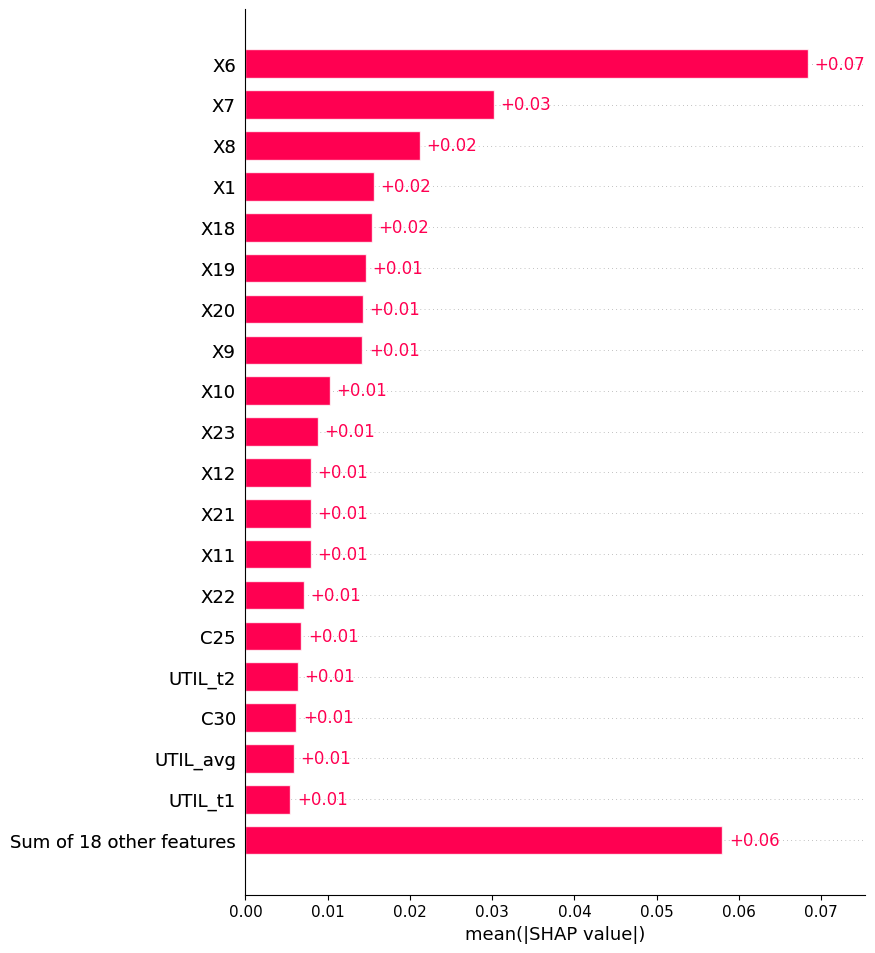

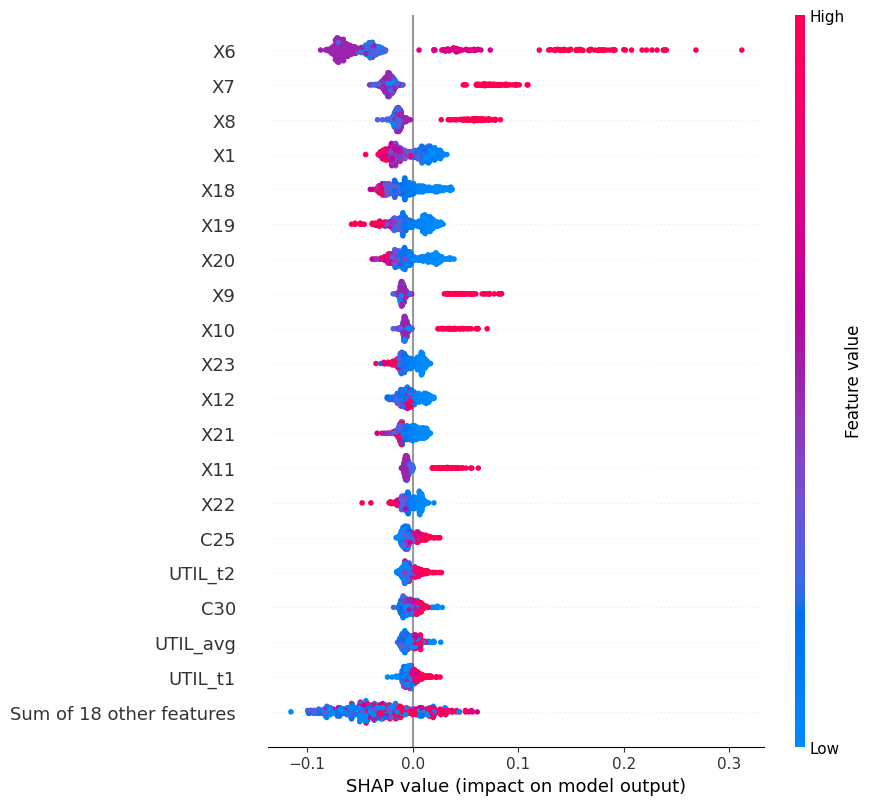

In [ ]:
# SHAP Feature Importance 

explainer = shap.TreeExplainer(rf_model)
X_sample = X_test.sample(500, random_state=42)

shap_explanation = explainer(X_sample)

if len(shap_explanation.values.shape) == 3:
    # Newer SHAP format - extract class 1
    shap_vals_class1 = shap_explanation.values[:, :, 1]
    shap_explanation_class1 = shap.Explanation(
        values=shap_vals_class1,
        base_values=shap_explanation.base_values[:, 1],
        data=shap_explanation.data,
        feature_names=X_sample.columns.tolist()
    )
else:
    shap_explanation_class1 = shap_explanation # in case of error

# Global bar plot
shap.plots.bar(shap_explanation_class1, 
               max_display=20,
               show=True)

# Beeswarm plot
shap.plots.beeswarm(shap_explanation_class1,
                    max_display=20,
                    show=True)

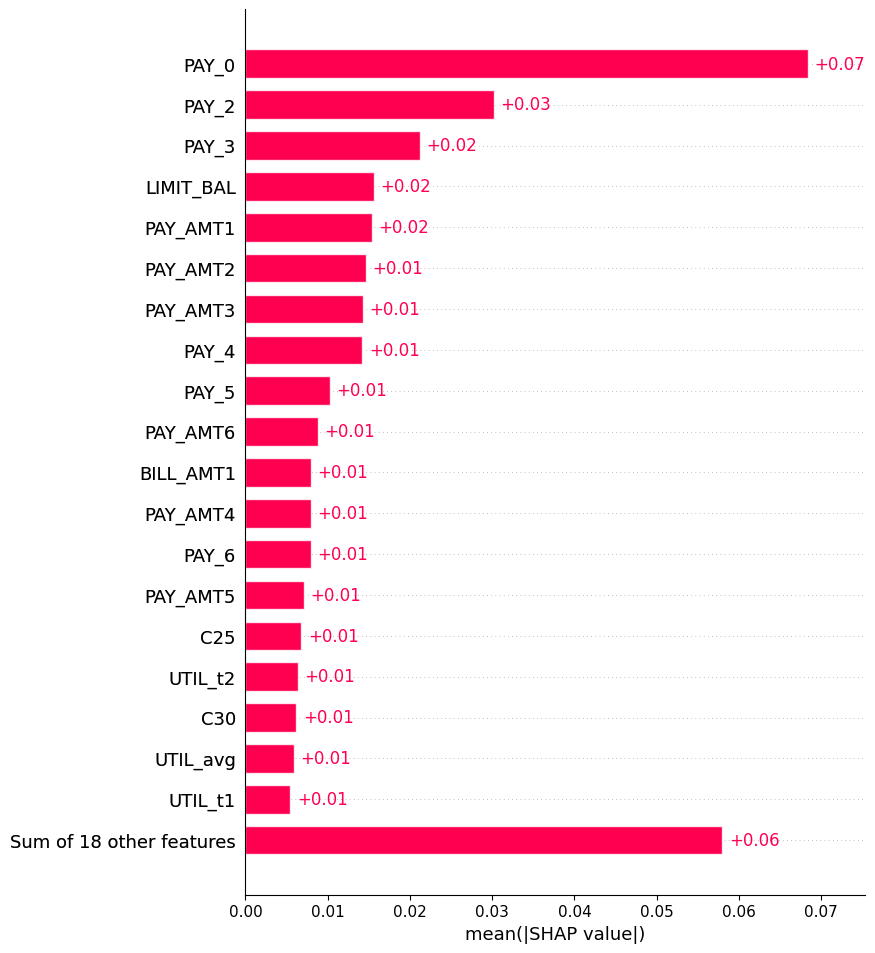

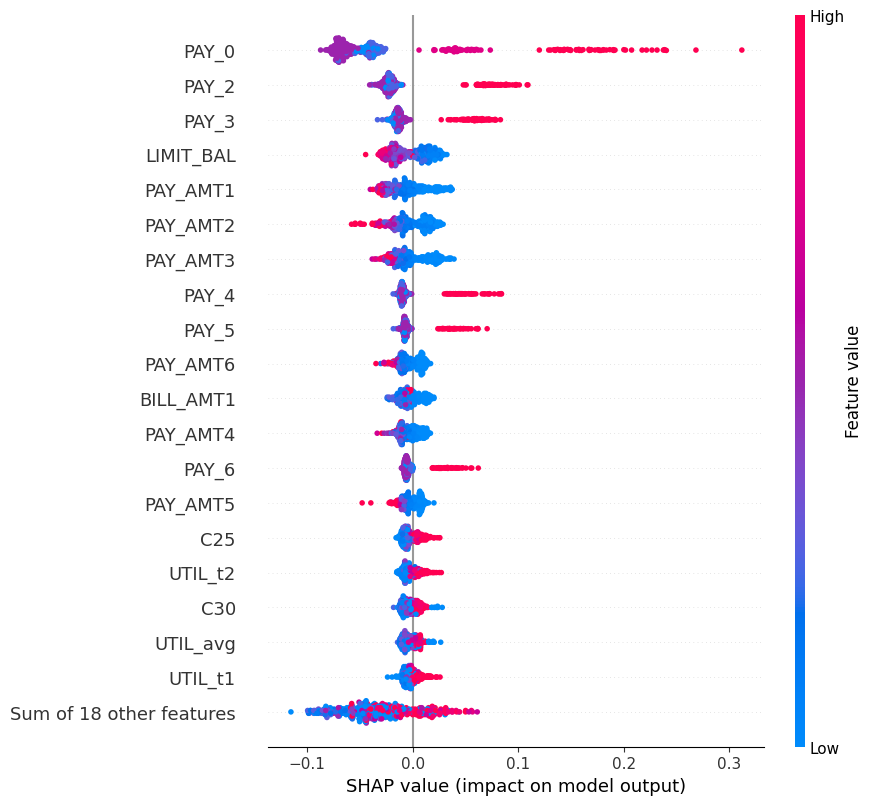

In [12]:

# Rename features for readable SHAP plot

feature_name_map = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6'
}

# Rename columns in sample
X_sample_named = X_sample.rename(columns=feature_name_map)

# Rebuild explanation
shap_explanation_named = shap.Explanation(
    values=shap_explanation_class1.values,
    base_values=shap_explanation_class1.base_values,
    data=X_sample_named.values,
    feature_names=X_sample_named.columns.tolist()
)

# Replot with readable names
shap.plots.bar(shap_explanation_named,
               max_display=20,
               show=True)

shap.plots.beeswarm(shap_explanation_named,
                    max_display=20,
                    show=True)

In [ ]:
# Counterfactual Helper Function
# Takes a dataset, applies an intervention, returns the mean change in predicted default probability

def run_intervention(model, X_original, intervention_fn, label):
    """
    intervention_fn: a function that takes a copy of X and 
                     returns the modified version
    """
    X_modified = intervention_fn(X_original.copy())
    
    prob_original = model.predict_proba(X_original)[:, 1]
    prob_modified = model.predict_proba(X_modified)[:, 1]
    
    delta_p = prob_modified - prob_original  # negative = reduction
    
    print(f"\n--- {label} ---")
    print(f"Mean ΔP(default)       : {delta_p.mean():.6f}")
    print(f"Mean |ΔP(default)|     : {np.abs(delta_p).mean():.6f}")
    print(f"Clients with reduction : "
          f"{(delta_p < 0).sum()} / {len(delta_p)}")
    
    return delta_p

In [ ]:
# Intervention A: Reduce Bill Amounts (Reduce Utilization)
# Simulate clients paying down their balance by 10%, 25%, 50%
# LIMIT_BAL (X1) stays the same, only BILL_AMTs change -- Utilization ratios are recomputed after the change

results_A = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_A(X, reduction=pct):
        X_mod = X.copy()
        # Reduce each bill amount column
        for col in bill_cols:
            X_mod[col] = X_mod[col] * (1 - reduction)
        # Recompute utilization ratios
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        # Clip to training min/max
        for col in bill_cols + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod
    
    delta = run_intervention(
        rf_model, X_test, intervention_A,
        f"Intervention A - Reduce Bill Amounts by {int(pct*100)}%"
    )
    results_A[pct] = delta


--- Intervention A - Reduce Bill Amounts by 10% ---
Mean ΔP(default)       : -0.002442
Mean |ΔP(default)|     : 0.008973
Clients with reduction : 1418 / 3000

--- Intervention A - Reduce Bill Amounts by 25% ---
Mean ΔP(default)       : -0.006063
Mean |ΔP(default)|     : 0.017334
Clients with reduction : 1466 / 3000

--- Intervention A - Reduce Bill Amounts by 50% ---
Mean ΔP(default)       : -0.008084
Mean |ΔP(default)|     : 0.030444
Clients with reduction : 1472 / 3000


In [ ]:
#  Intervention B: Increase Credit Limit
# Simulate lender increasing LIMIT_BAL (X1) by 10%, 25%, 50% -- Bill amounts stay the same, utilization ratios recomputed

results_B = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_B(X, increase=pct):
        X_mod = X.copy()
        # Increase credit limit
        X_mod['X1'] = X_mod['X1'] * (1 + increase)
        # Recompute utilization ratios with new limit
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        # Clip to training distribution
        for col in ['X1'] + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod
    
    delta = run_intervention(
        rf_model, X_test, intervention_B,
        f"Intervention B - Increase Credit Limit by {int(pct*100)}%"
    )
    results_B[pct] = delta


--- Intervention B - Increase Credit Limit by 10% ---
Mean ΔP(default)       : -0.004192
Mean |ΔP(default)|     : 0.007825
Clients with reduction : 1986 / 3000

--- Intervention B - Increase Credit Limit by 25% ---
Mean ΔP(default)       : -0.009678
Mean |ΔP(default)|     : 0.013723
Clients with reduction : 2162 / 3000

--- Intervention B - Increase Credit Limit by 50% ---
Mean ΔP(default)       : -0.016538
Mean |ΔP(default)|     : 0.020887
Clients with reduction : 2255 / 3000


In [ ]:
# Intervention C: Increase Limit, Hold Utilization Constant
# Isolates the pure limit effect by increasing both limit and bill amounts proportionally so utilization doesn't change

results_C = {}

for pct in [0.10, 0.25, 0.50]:
    def intervention_C(X, increase=pct):
        X_mod = X.copy()
        # Increase both limit and bills proportionally
        X_mod['X1'] = X_mod['X1'] * (1 + increase)
        for col in bill_cols:
            X_mod[col] = X_mod[col] * (1 + increase)
        # Utilization stays the same mathematically but recompute to be safe
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        for col in ['X1'] + bill_cols + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod
    
    delta = run_intervention(
        rf_model, X_test, intervention_C,
        f"Intervention C - Increase Limit+Bills by {int(pct*100)}% "
        f"(Utilization Held Constant)"
    )
    results_C[pct] = delta


--- Intervention C - Increase Limit+Bills by 10% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.001963
Mean |ΔP(default)|     : 0.005235
Clients with reduction : 1965 / 3000

--- Intervention C - Increase Limit+Bills by 25% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.004480
Mean |ΔP(default)|     : 0.010404
Clients with reduction : 2086 / 3000

--- Intervention C - Increase Limit+Bills by 50% (Utilization Held Constant) ---
Mean ΔP(default)       : -0.007865
Mean |ΔP(default)|     : 0.016731
Clients with reduction : 2090 / 3000


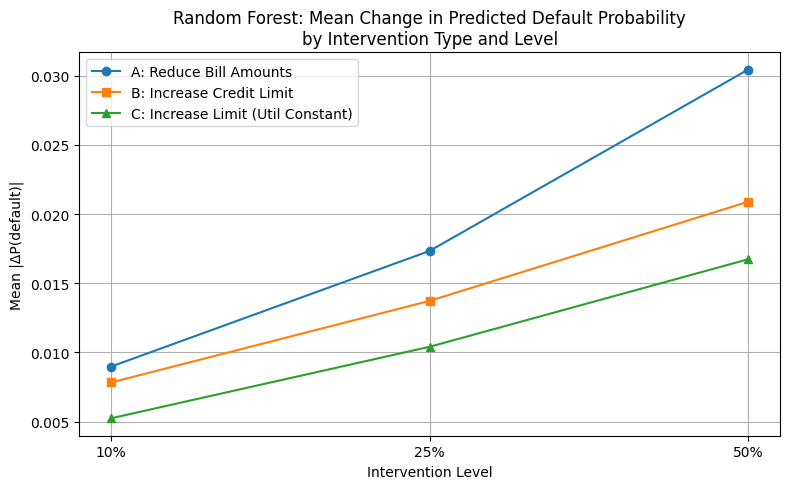

In [ ]:
# Summary Comparison Plot
# Line chart of mean |ΔP| vs intervention level for all three interventions

levels = [0.10, 0.25, 0.50]
labels = ['10%', '25%', '50%']

mean_A = [np.abs(results_A[p]).mean() for p in levels]
mean_B = [np.abs(results_B[p]).mean() for p in levels]
mean_C = [np.abs(results_C[p]).mean() for p in levels]

plt.figure(figsize=(8, 5))
plt.plot(labels, mean_A, marker='o', label='A: Reduce Bill Amounts')
plt.plot(labels, mean_B, marker='s', label='B: Increase Credit Limit')
plt.plot(labels, mean_C, marker='^', 
         label='C: Increase Limit (Util Constant)')
plt.xlabel('Intervention Level')
plt.ylabel('Mean |ΔP(default)|')
plt.title('Random Forest: Mean Change in Predicted Default Probability\n'
          'by Intervention Type and Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('RF_counterfactual_comparison.png', dpi=150)
plt.show()

In [ ]:
# Client Segmentation Analysis

baseline_probs = rf_model.predict_proba(X_test)[:, 1]

high_risk_mask = baseline_probs > 0.5
low_risk_mask  = baseline_probs < 0.4  # lowered from 0.2

print(f"High-risk clients (P > 0.5): {high_risk_mask.sum()}")
print(f"Low-risk clients  (P < 0.4): {low_risk_mask.sum()}")

for mask, group_label in [(high_risk_mask, 'High-Risk'),
                           (low_risk_mask,  'Low-Risk')]:
    X_group = X_test[mask]
    
    # Skip if group is empty
    if len(X_group) == 0:
        print(f"\n{group_label} group is empty, skipping.")
        continue
        
    print(f"\n=== {group_label} Group (n={len(X_group)}) ===")

    def int_A_seg(X):
        X_mod = X.copy()
        for col in bill_cols:
            X_mod[col] = X_mod[col] * 0.75
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        for col in bill_cols + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod

    def int_B_seg(X):
        X_mod = X.copy()
        X_mod['X1'] = X_mod['X1'] * 1.25
        for bill, util in zip(bill_cols, util_col_names):
            X_mod[util] = X_mod[bill] / X_mod['X1'].replace(0, np.nan)
        X_mod['UTIL_avg'] = X_mod[util_col_names].mean(axis=1)
        for col in ['X1'] + util_col_names + ['UTIL_avg']:
            X_mod[col] = X_mod[col].clip(
                X_train[col].min(), X_train[col].max()
            )
        return X_mod

    run_intervention(rf_model, X_group, int_A_seg,
        f"{group_label} - Intervention A (25% bill reduction)")

    run_intervention(rf_model, X_group, int_B_seg,
        f"{group_label} - Intervention B (25% limit increase)")
    

High-risk clients (P > 0.5): 696
Low-risk clients  (P < 0.4): 1841

=== High-Risk Group (n=696) ===

--- High-Risk - Intervention A (25% bill reduction) ---
Mean ΔP(default)       : -0.012108
Mean |ΔP(default)|     : 0.019492
Clients with reduction : 458 / 696

--- High-Risk - Intervention B (25% limit increase) ---
Mean ΔP(default)       : -0.008001
Mean |ΔP(default)|     : 0.016302
Clients with reduction : 450 / 696

=== Low-Risk Group (n=1841) ===

--- Low-Risk - Intervention A (25% bill reduction) ---
Mean ΔP(default)       : -0.002094
Mean |ΔP(default)|     : 0.015366
Clients with reduction : 723 / 1841

--- Low-Risk - Intervention B (25% limit increase) ---
Mean ΔP(default)       : -0.009521
Mean |ΔP(default)|     : 0.011803
Clients with reduction : 1382 / 1841
